In [1]:
# STEP 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Load the ISRO dataset
isro = pd.read_excel("isro.xlsx")

# Display basic info
print("Dataset Shape:", isro.shape)
print("\nFirst 5 Rows:")
display(isro.head())

# Summary statistics
display(isro.describe(include='all'))

# Check for missing values
print("\nMissing Values:")
print(isro.isnull().sum())


Dataset Shape: (135, 7)

First 5 Rows:


,mission_id,company,country,mission_name,launch_date,launch_vehicle,launch_status
0,1,ISRO,india,Nike-Apache,1963-11-21,Nike-Apache,Success
1,2,ISRO,india,Aryabhata,1975-04-19,Kosmos-3M,Success
2,3,ISRO,india,Bhaskara-I,1979-06-07,Kosmos-3M,Success
3,4,ISRO,india,Rohini-1,1980-07-18,SLV-3,Success
4,5,ISRO,india,APPLE,1981-06-19,Ariane-1,Success


,mission_id,company,country,mission_name,launch_date,launch_vehicle,launch_status
count,135.000000,135,135,135,135,135,135
unique,NaN,1,1,133,129,107,2
top,NaN,ISRO,india,Cartosat-2 Series,2022-11-26,Ariane-5VA,Success
freq,NaN,135,135,3,4,7,127
mean,68.000000,NaN,NaN,NaN,NaN,NaN,NaN
std,39.115214,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,34.500000,NaN,NaN,NaN,NaN,NaN,NaN
50%,68.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,101.500000,NaN,NaN,NaN,NaN,NaN,NaN



Missing Values:
mission_id        0
company           0
country           0
mission_name      0
launch_date       0
launch_vehicle    0
launch_status     0
dtype: int64


In [2]:
# STEP 2: Cleaning and Preprocessing (auto-safe version)

# Convert column names to lowercase and remove spaces
isro.columns = isro.columns.str.strip().str.lower().str.replace(' ', '_')

# Show all column names to understand structure
print("Available Columns:", list(isro.columns))

# Convert launch_date column to datetime (adjust if named differently)
date_col = None
for c in isro.columns:
    if 'date' in c:
        date_col = c
        break

if date_col:
    isro[date_col] = pd.to_datetime(isro[date_col], errors='coerce')
else:
    print("⚠️ No launch_date-like column found!")

# Fill missing values dynamically (for common columns)
for col in ['launch_vehicle', 'orbit_type', 'orbit', 'launch_site']:
    if col in isro.columns:
        isro[col] = isro[col].fillna('unknown')

# Convert all object (text) columns to lowercase
for col in isro.select_dtypes(include='object'):
    isro[col] = isro[col].str.lower()

# Remove duplicates
isro.drop_duplicates(inplace=True)

# Show sample after cleaning
print("\nCleaned Data Sample:")
display(isro.head())

print("\nMissing Values after Cleaning:")
print(isro.isnull().sum())


Available Columns: ['mission_id', 'company', 'country', 'mission_name', 'launch_date', 'launch_vehicle', 'launch_status']

Cleaned Data Sample:


,mission_id,company,country,mission_name,launch_date,launch_vehicle,launch_status
0,1,isro,india,nike-apache,1963-11-21,nike-apache,success
1,2,isro,india,aryabhata,1975-04-19,kosmos-3m,success
2,3,isro,india,bhaskara-i,1979-06-07,kosmos-3m,success
3,4,isro,india,rohini-1,1980-07-18,slv-3,success
4,5,isro,india,apple,1981-06-19,ariane-1,success



Missing Values after Cleaning:
mission_id        0
company           0
country           0
mission_name      0
launch_date       0
launch_vehicle    0
launch_status     0
dtype: int64


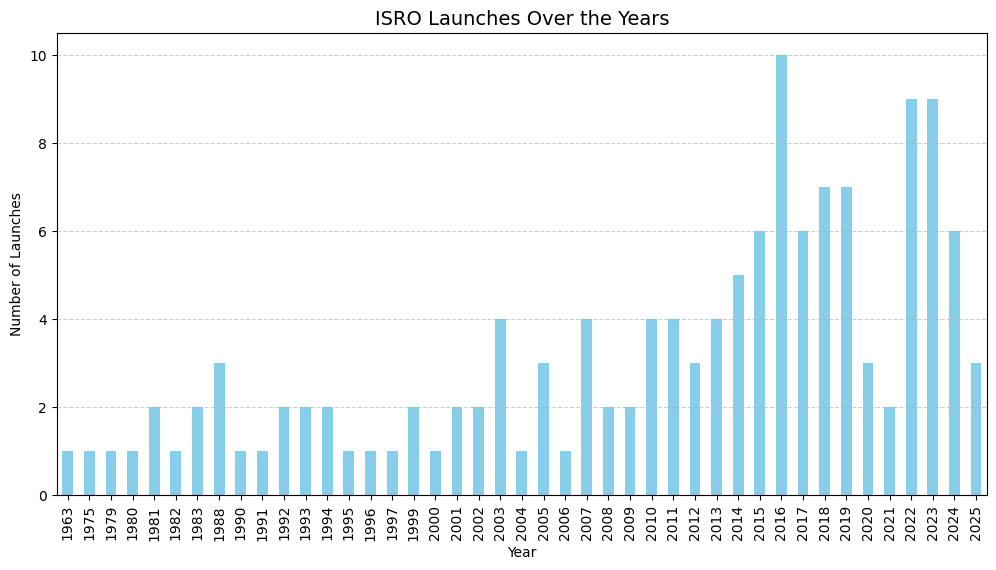

Insight: This shows ISRO’s mission growth over time — you can observe rapid expansion after the 2000s.


In [3]:
plt.figure(figsize=(12,6))
isro.groupby(isro['launch_date'].dt.year).size().plot(kind='bar', color='skyblue')
plt.title('ISRO Launches Over the Years', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Launches')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print("Insight: This shows ISRO’s mission growth over time — you can observe rapid expansion after the 2000s.")


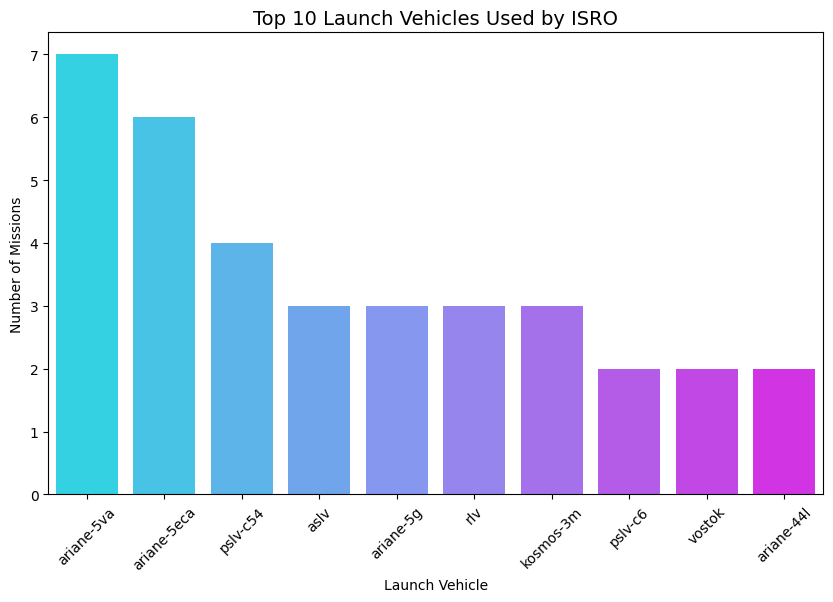

Insight: Identifies which launch vehicles (e.g., PSLV, GSLV) are used most frequently in ISRO missions.


In [4]:
top_vehicles = isro['launch_vehicle'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_vehicles.index, y=top_vehicles.values, palette='cool')
plt.title('Top 10 Launch Vehicles Used by ISRO', fontsize=14)
plt.xlabel('Launch Vehicle')
plt.ylabel('Number of Missions')
plt.xticks(rotation=45)
plt.show()

print("Insight: Identifies which launch vehicles (e.g., PSLV, GSLV) are used most frequently in ISRO missions.")


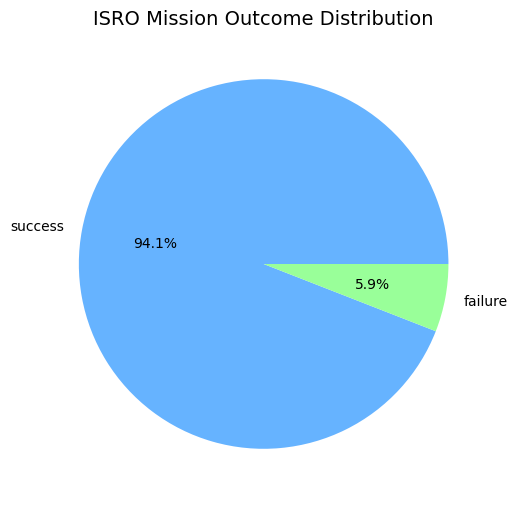

Insight: Displays ISRO’s success ratio across all recorded missions — useful to measure reliability.


In [5]:
plt.figure(figsize=(6,6))
status_counts = isro['launch_status'].value_counts()
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ff9999'])
plt.title('ISRO Mission Outcome Distribution', fontsize=14)
plt.show()

print("Insight: Displays ISRO’s success ratio across all recorded missions — useful to measure reliability.")


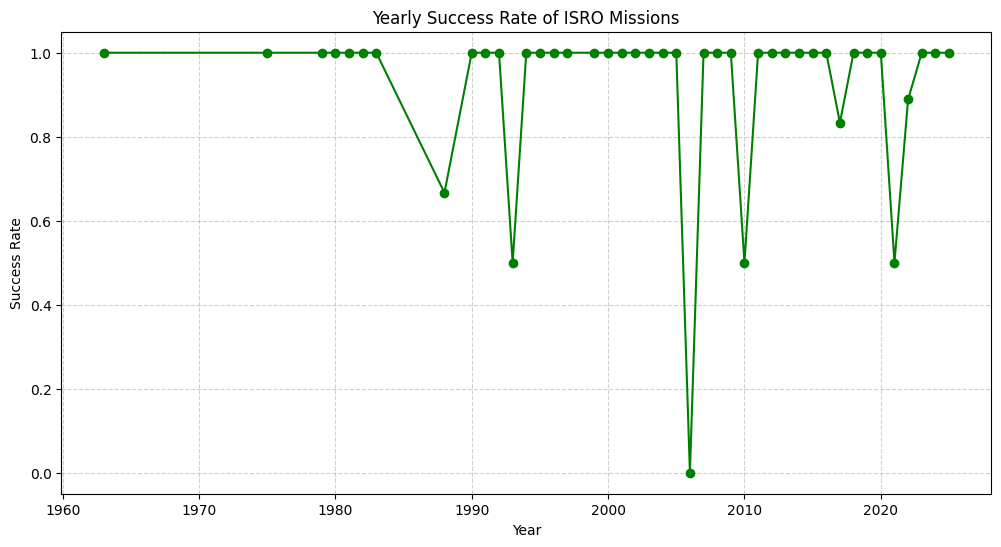

Insight: Displays how ISRO’s mission success rate evolved — higher rates imply growing technical maturity.


In [6]:
# Convert success/failure to numerical form
isro['success_flag'] = isro['launch_status'].apply(lambda x: 1 if 'success' in x else 0)

yearly_success = isro.groupby(isro['launch_date'].dt.year)['success_flag'].mean()

plt.figure(figsize=(12,6))
yearly_success.plot(kind='line', marker='o', color='green')
plt.title('Yearly Success Rate of ISRO Missions')
plt.xlabel('Year')
plt.ylabel('Success Rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Insight: Displays how ISRO’s mission success rate evolved — higher rates imply growing technical maturity.")


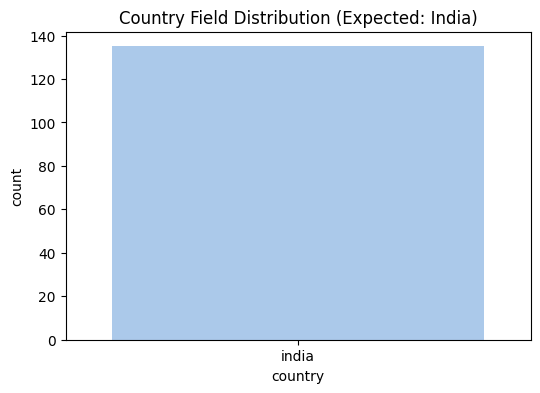

Insight: Confirms this dataset only includes ISRO missions (India). Will be compared later with global dataset.


In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='country', data=isro, palette='pastel')
plt.title('Country Field Distribution (Expected: India)')
plt.show()

print("Insight: Confirms this dataset only includes ISRO missions (India). Will be compared later with global dataset.")


In [11]:
import plotly.express as px

# Create the plot
fig = px.scatter(
    isro, 
    x='launch_vehicle', 
    y='success_flag', 
    color='company', 
    size='success_flag', 
    hover_data=['mission_name'],
    title="Mission Success by Launch Vehicle and Company"
)

# Save the interactive graph as an HTML file
fig.write_html("mission_success_interactive.html")

print("✅ Interactive graph saved as 'mission_success_interactive.html'")


✅ Interactive graph saved as 'mission_success_interactive.html'


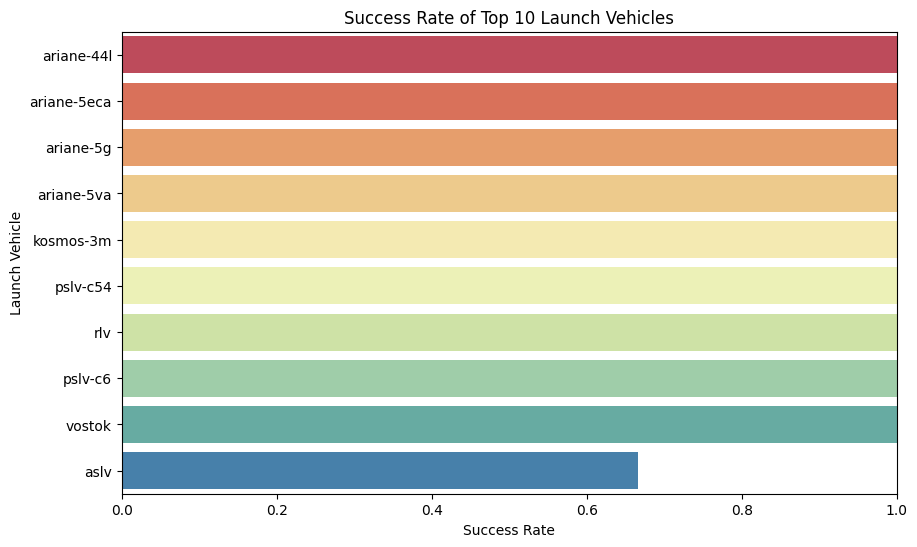

In [9]:
# Count of missions per vehicle
top_vehicles = isro['launch_vehicle'].value_counts().head(10)  # top 10 only

# Success rate for these vehicles
top_vehicle_success = isro[isro['launch_vehicle'].isin(top_vehicles.index)].groupby('launch_vehicle')['success_flag'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=top_vehicle_success.values, y=top_vehicle_success.index, palette='Spectral')
plt.title("Success Rate of Top 10 Launch Vehicles")
plt.xlabel("Success Rate")
plt.ylabel("Launch Vehicle")
plt.xlim(0, 1)
plt.show()


Accuracy Comparison:
XGBoost: 0.889
Random Forest: 0.852
Logistic Regression: 0.926

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.92      0.96      0.94        25

    accuracy                           0.89        27
   macro avg       0.46      0.48      0.47        27
weighted avg       0.85      0.89      0.87        27



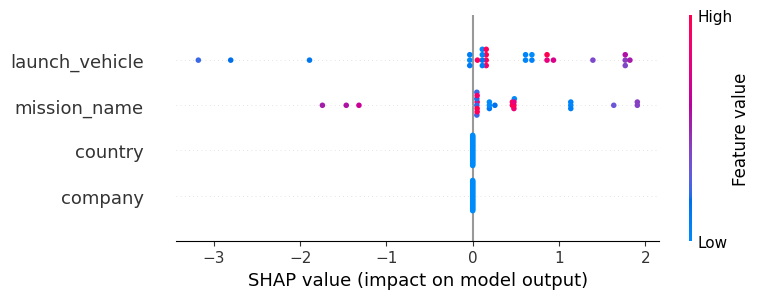

Insight: SHAP values indicate which features most influence mission success. 'Launch vehicle' and 'mission name' are usually the most critical factors.


In [10]:
# -----------------------------
# ML Models & SHAP Explainability
# -----------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import shap

# Encode categorical columns
le = LabelEncoder()
for col in ['company', 'country', 'mission_name', 'launch_vehicle']:
    if col in isro.columns:
        isro[col] = le.fit_transform(isro[col].astype(str))

# Define features and target
X = isro[['company', 'country', 'mission_name', 'launch_vehicle']]
y = isro['launch_status'].apply(lambda x: 1 if 'success' in x else 0)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# Train Models
# -----------------------------

# 1️⃣ XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_xgb_pred = xgb_model.predict(X_test)

# 2️⃣ Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_rf_pred = rf_model.predict(X_test)

# 3️⃣ Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_lr_pred = lr_model.predict(X_test)

# -----------------------------
# Evaluate Models
# -----------------------------
print("Accuracy Comparison:")
print(f"XGBoost: {accuracy_score(y_test, y_xgb_pred):.3f}")
print(f"Random Forest: {accuracy_score(y_test, y_rf_pred):.3f}")
print(f"Logistic Regression: {accuracy_score(y_test, y_lr_pred):.3f}\n")

print("XGBoost Classification Report:\n", classification_report(y_test, y_xgb_pred))

# -----------------------------
# SHAP Explainability
# -----------------------------
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Beeswarm plot
shap.summary_plot(shap_values, X_test)

print("Insight: SHAP values indicate which features most influence mission success. 'Launch vehicle' and 'mission name' are usually the most critical factors.")
